In [14]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy import sparse

sns.set_theme(style="whitegrid")
sc.settings.verbosity = 2
sc.set_figure_params(dpi=120, facecolor="white")

DATA_PATH = Path(r"C:\Users\Peter\OneDrive\Documents\Kunstig intelligens 4. semester\Fagproject\Head files\hematopoiesis_GSE129785_FACS_sorted.h5ad")
assert DATA_PATH.exists(), f"Missing file: {DATA_PATH}"

In [15]:
adata = sc.read_h5ad(DATA_PATH)

print(adata)
print(f"Shape: {adata.n_obs:,} cells x {adata.n_vars:,} features")
print("obs columns:", list(adata.obs.columns))
print("var columns:", list(adata.var.columns))

X = adata.X
if sparse.issparse(X):
    sample = X.data
    density = X.nnz / (X.shape[0] * X.shape[1])
else:
    sample = np.asarray(X).ravel()
    density = np.count_nonzero(sample) / sample.size

if sample.size:
    sample_view = sample[: min(sample.size, 10000)]
    integer_like = np.allclose(sample_view, np.round(sample_view))
    print(f"Matrix density: {density:.4f}")
    print(f"Value range: {sample.min():.4f} to {sample.max():.4f}")
    print(f"Integer-like values: {integer_like}")
else:
    print("Matrix appears to be empty.")

c:\Users\Peter\OneDrive\Documents\Kunstig intelligens 4. semester\Fagproject\Head files\.venv\Lib\site-packages\anndata\_core\anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 34225 × 571400
    obs: 'UMAP1', 'UMAP2', 'Clusters', 'Group', 'depth', 'FRIP', 'Internal_Name', 'Group_Barcode', 'cell_type'
    var: 'Feature'
Shape: 34,225 cells x 571,400 features
obs columns: ['UMAP1', 'UMAP2', 'Clusters', 'Group', 'depth', 'FRIP', 'Internal_Name', 'Group_Barcode', 'cell_type']
var columns: ['Feature']
Matrix density: 0.0135
Value range: 1.0000 to 57.0000
Integer-like values: True


In [16]:
adata_pca = adata.copy()
X = adata_pca.X
sample = X.data if sparse.issparse(X) else np.asarray(X).ravel()
sample_view = sample[: min(sample.size, 10000)] if sample.size else sample

if sample.size and (np.allclose(sample_view, np.round(sample_view)) or sample.max() > 1000):
    sc.pp.normalize_total(adata_pca, target_sum=1e4)
    sc.pp.log1p(adata_pca)
    print("Applied library-size normalization and log1p transformation.")
else:
    print("Data already looks normalized or transformed; continuing without renormalizing.")

if adata_pca.n_vars > 2000:
    sc.pp.highly_variable_genes(adata_pca, n_top_genes=2000, flavor="seurat")
    adata_pca = adata_pca[:, adata_pca.var["highly_variable"]].copy()
    print(f"Restricted to {adata_pca.n_vars:,} highly variable features.")

sc.pp.scale(adata_pca, max_value=10)
sc.tl.pca(adata_pca, n_comps=50, svd_solver="arpack")
print(adata_pca.obsm["X_pca"].shape)
print(adata_pca.uns["pca"]["variance_ratio"][:10])

normalizing counts per cell
    finished (0:00:01)
Applied library-size normalization and log1p transformation.
extracting highly variable genes
    finished (0:00:05)


c:\Users\Peter\OneDrive\Documents\Kunstig intelligens 4. semester\Fagproject\Head files\.venv\Lib\site-packages\anndata\_core\anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
C:\Users\Peter\AppData\Roaming\uv\python\cpython-3.12.11-windows-x86_64-none\Lib\functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Restricted to 2,000 highly variable features.
computing PCA
    with n_comps=50
    finished (0:00:08)
(34225, 50)
[0.01569688 0.0081044  0.00566044 0.00494565 0.0047546  0.00435512
 0.00411907 0.00409477 0.00393918 0.0037795 ]


In [20]:
variance_ratio = adata_pca.uns["pca"]["variance_ratio"]
n_components = min(10, len(variance_ratio))
explained_variance = pd.DataFrame(
    {
        "PC": [f"PC{i}" for i in range(1, n_components + 1)],
        "Explained variance ratio": variance_ratio[:n_components],
        "Cumulative explained variance": np.cumsum(variance_ratio[:n_components]),
    }
)

print(f"Cumulative explained variance (first {n_components} PCs): {explained_variance['Cumulative explained variance'].iloc[-1]:.2%}")
display(explained_variance)


Cumulative explained variance (first 10 PCs): 5.94%


,PC,Explained variance ratio,Cumulative explained variance
0,PC1,0.015697,0.015697
1,PC2,0.008104,0.023801
2,PC3,0.005660,0.029462
3,PC4,0.004946,0.034407
4,PC5,0.004755,0.039162
5,PC6,0.004355,0.043517
6,PC7,0.004119,0.047636
7,PC8,0.004095,0.051731
8,PC9,0.003939,0.055670
9,PC10,0.003780,0.059450


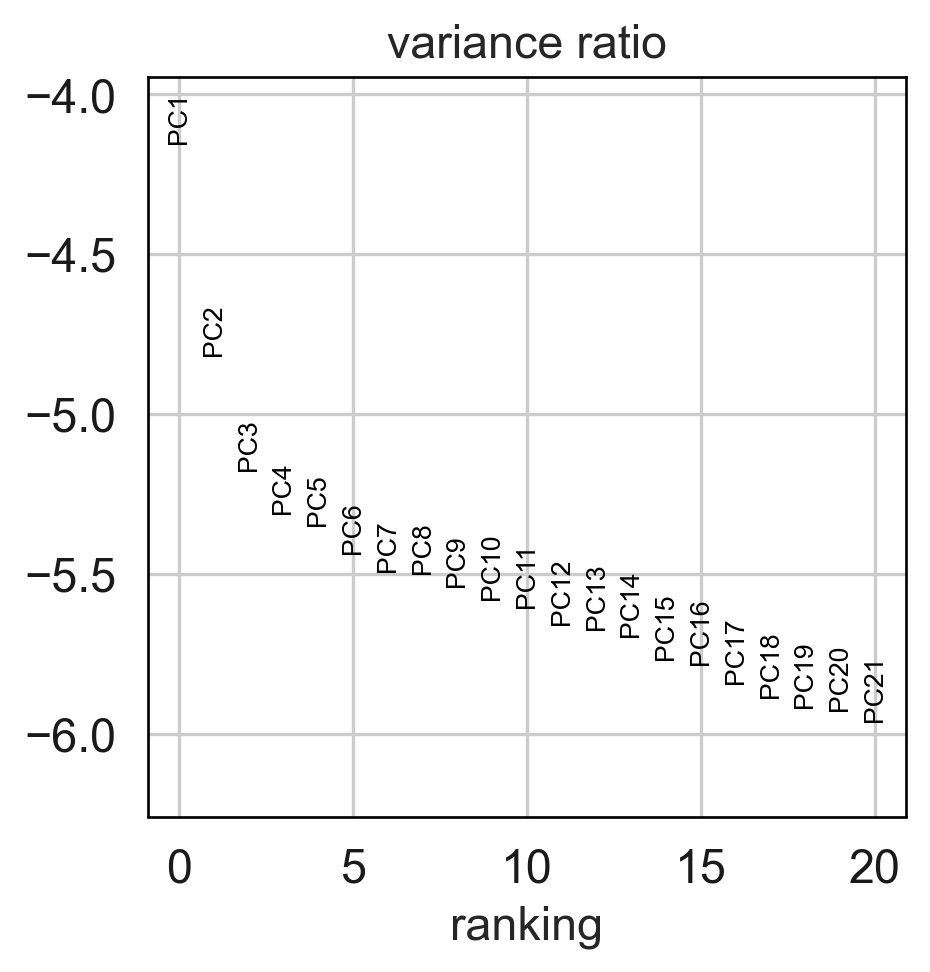

Suggested annotation columns for coloring: ['cell_type']


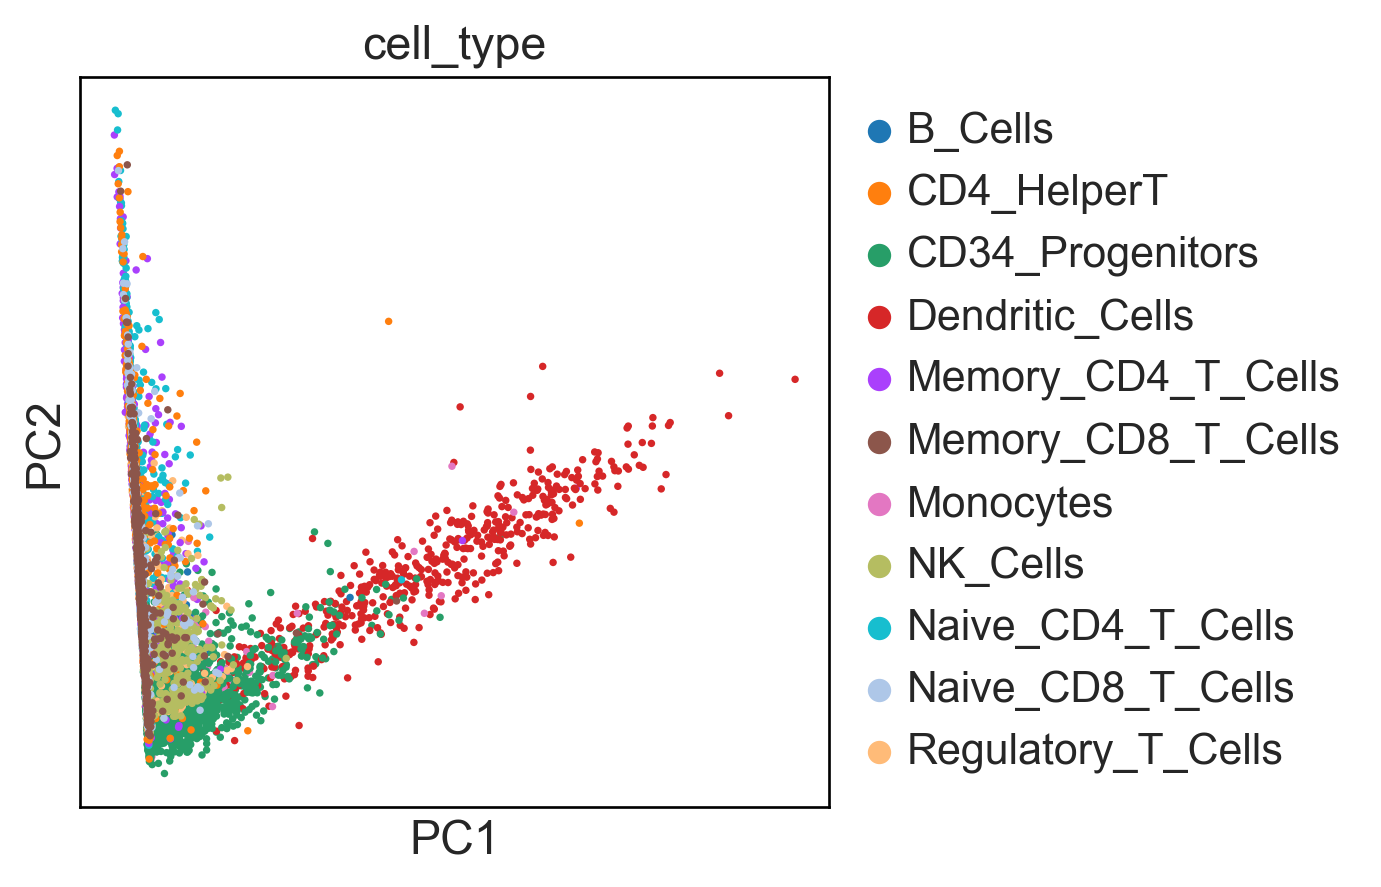

In [17]:
sc.pl.pca_variance_ratio(adata_pca, n_pcs=20, log=True)

candidate_labels = [
    column
    for column in ["cell_type", "celltype", "celltypes", "louvain", "leiden", "clusters", "batch_id", "batch", "donor"]
    if column in adata_pca.obs.columns
]
print("Suggested annotation columns for coloring:", candidate_labels)

color_by = candidate_labels[0] if candidate_labels else None
sc.pl.pca(adata_pca, color=color_by, size=20)